# Transfer Learning & Fine-Tuning

## From a pretrained CNN to a reliable custom classifier

**Framework:** TensorFlow / Keras  
**Backbone:** MobileNetV2 pretrained on ImageNet  
**Dataset:** Cats vs. Dogs  
**Level:** Intermediate AI Model Development Bootcamp

In this notebook, we will first use a pretrained CNN as a **frozen feature extractor**, then selectively unfreeze its upper layers and adapt them using **fine-tuning**.


## Learning objectives

By the end of this notebook, you should be able to:

1. Explain the difference between training from scratch, transfer learning, and fine-tuning.
2. Load a pretrained CNN without its original classifier.
3. Freeze a backbone and train a new classification head.
4. Selectively unfreeze upper layers for fine-tuning.
5. Recompile with a smaller learning rate after changing trainable layers.
6. Compare frozen-feature and fine-tuned models using validation and test results.
7. Diagnose overfitting and decide whether to change the data or the model.


## 1. The core idea

A CNN trained on a large, diverse dataset learns reusable visual representations:

- Early layers often detect edges, colors, and simple textures.
- Middle layers combine them into shapes and object parts.
- Upper layers become more specialized for the original task.

| Approach | Starting weights | What is trained? | Typical use |
|---|---|---|---|
| Training from scratch | Random | Entire network | Large custom dataset or very different domain |
| Transfer learning | Pretrained | New classification head | Small or medium dataset with related visual content |
| Fine-tuning | Pretrained + trained head | Some upper backbone layers + head | Adapt high-level features after the head is stable |

**Important:** Fine-tuning is usually the second stage of transfer learning, not the first step.


## 2. Recommended workflow

1. Load a model pretrained on a large source dataset.
2. Remove its original classifier using <code>include_top=False</code>.
3. Freeze the pretrained backbone.
4. Add a new task-specific classification head.
5. Train the new head until it becomes stable.
6. Unfreeze a small number of upper backbone layers.
7. Recompile using a much smaller learning rate.
8. Fine-tune carefully and monitor validation performance.

This order protects useful pretrained representations from large, unstable updates caused by a randomly initialized head.


## 3. Setup

For faster training in Google Colab, select **Runtime → Change runtime type → GPU**.


In [1]:
import sys; print(sys.executable)
import keras; print(keras.__version__)

/Users/rmsaah/PycharmProjects/TuwaiqClasses/.venv312/bin/python


2026-08-30 20:37:53.401322: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


3.3.3


In [2]:
import sys, importlib.util
for p in sys.path: print(p)
print("jax ->", (importlib.util.find_spec("jax") or {}) and importlib.util.find_spec("jax").origin)

/Users/rmsaah/PycharmProjects/TuwaiqClasses

/Users/rmsaah/PycharmProjects/TuwaiqClasses/.venv312/lib/python3.12/site-packages
/Users/rmsaah/PycharmProjects/TuwaiqClasses/.venv312/lib/python3.12/site-packages/keras/src/backend
/Users/rmsaah/Applications/PyCharm.app/Contents/plugins/python-ce/helpers
/Library/Frameworks/Python.framework/Versions/3.12/lib/python312.zip
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/lib-dynload
/Users/rmsaah/PycharmProjects/TuwaiqClasses/.venv312/lib/python3.12/site-packages/setuptools/_vendor
jax -> /Users/rmsaah/PycharmProjects/TuwaiqClasses/.venv312/lib/python3.12/site-packages/keras/src/backend/jax/__init__.py


In [3]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.16.2
GPU devices: []


In [4]:
# Reproducibility and main configuration
SEED = 42
IMG_SIZE = (160, 160)
BATCH_SIZE = 32
INITIAL_EPOCHS = 5
FINE_TUNE_EPOCHS = 5

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE

FROZEN_MODEL_PATH = "best_transfer_model.keras"
FINE_TUNED_MODEL_PATH = "best_fine_tuned_model.keras"


## 4. Download and load the dataset

The dataset contains separate training and validation folders for two classes: **cats** and **dogs**. We will divide the supplied validation folder into validation and test subsets.

The test set must remain unseen during model selection. Use validation results to make decisions, then use the test set once for the final comparison.


In [5]:
import shutil

import certifi

os.environ["SSL_CERT_FILE"] = certifi.where()

DATA_URL = "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"

archive_path = Path(
    tf.keras.utils.get_file(
        fname="kagglecatsanddogs_5340.zip",
        origin=DATA_URL,
        extract=True,
    )
)

cache_dir = archive_path if archive_path.is_dir() else archive_path.parent
pet_images = next(p for p in cache_dir.rglob("PetImages") if p.is_dir())

data_root = cache_dir / "cats_and_dogs_filtered"
train_dir = data_root / "train"
validation_dir = data_root / "validation"

SPLIT_SIZES = {"train": 1000, "validation": 500}

if not data_root.exists():
    for source_name, class_name in (("Cat", "cats"), ("Dog", "dogs")):
        usable = []
        for image_path in sorted((pet_images / source_name).glob("*.jpg")):
            try:
                tf.io.decode_jpeg(tf.io.read_file(str(image_path)))
            except Exception:
                continue
            usable.append(image_path)
            if len(usable) == sum(SPLIT_SIZES.values()):
                break

        offset = 0
        for split_name, count in SPLIT_SIZES.items():
            target_dir = data_root / split_name / class_name
            target_dir.mkdir(parents=True, exist_ok=True)
            for image_path in usable[offset : offset + count]:
                shutil.copy2(image_path, target_dir / image_path.name)
            offset += count

print("Training directory:", train_dir)
print("Validation directory:", validation_dir)


Training directory: /Users/rmsaah/.keras/datasets/cats_and_dogs_filtered/train
Validation directory: /Users/rmsaah/.keras/datasets/cats_and_dogs_filtered/validation


In [6]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    validation_split=0.5,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    validation_split=0.5,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

class_names = train_dataset.class_names
print("Classes:", class_names)
print("Training batches:", tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation batches:", tf.data.experimental.cardinality(validation_dataset).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_dataset).numpy())


Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Using 500 files for training.
Found 1000 files belonging to 2 classes.
Using 500 files for validation.
Classes: ['cats', 'dogs']
Training batches: 63
Validation batches: 16
Test batches: 16


### Inspect examples before training

Always inspect images and labels before building the model. This catches incorrect folders, corrupted examples, unexpected image styles, and labeling problems early.


2026-08-30 20:38:19.096013: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


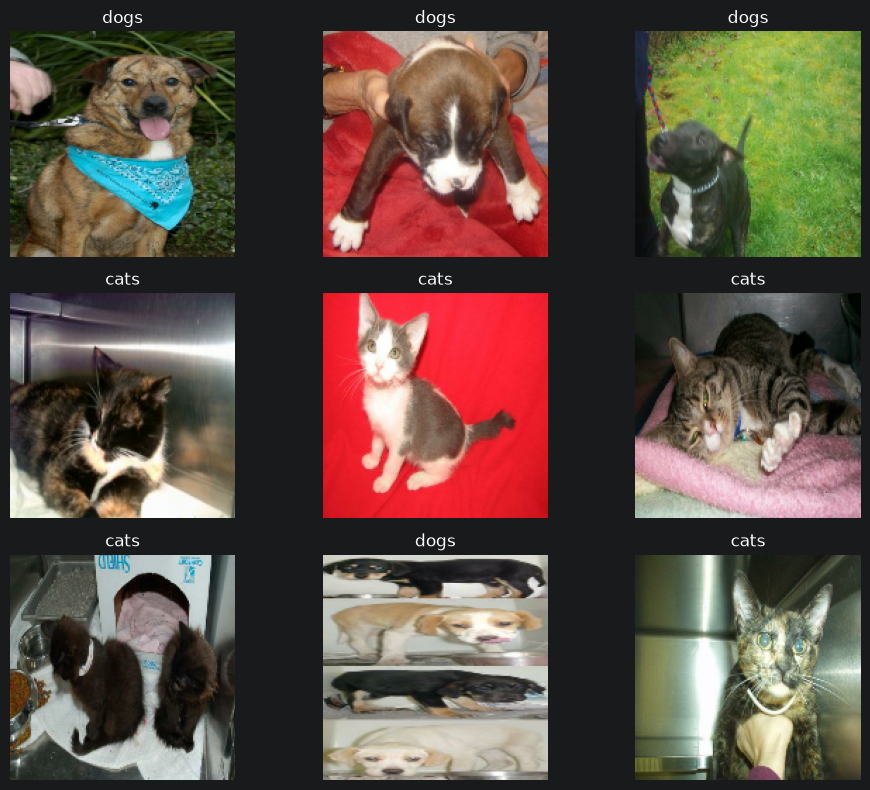

In [7]:
plt.figure(figsize=(10, 8))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

plt.tight_layout()
plt.show()


## 5. Build an efficient input pipeline

<code>prefetch</code> overlaps CPU data preparation with GPU training. We avoid caching all augmented training images because augmentation should remain random between epochs.


In [8]:
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)


## 6. Data augmentation

Transfer learning is often used with limited data. Data augmentation creates realistic variations during training and helps reduce overfitting.


In [9]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.05),
        tf.keras.layers.RandomZoom(0.10),
    ],
    name="data_augmentation",
)


2026-08-30 20:38:19.932196: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


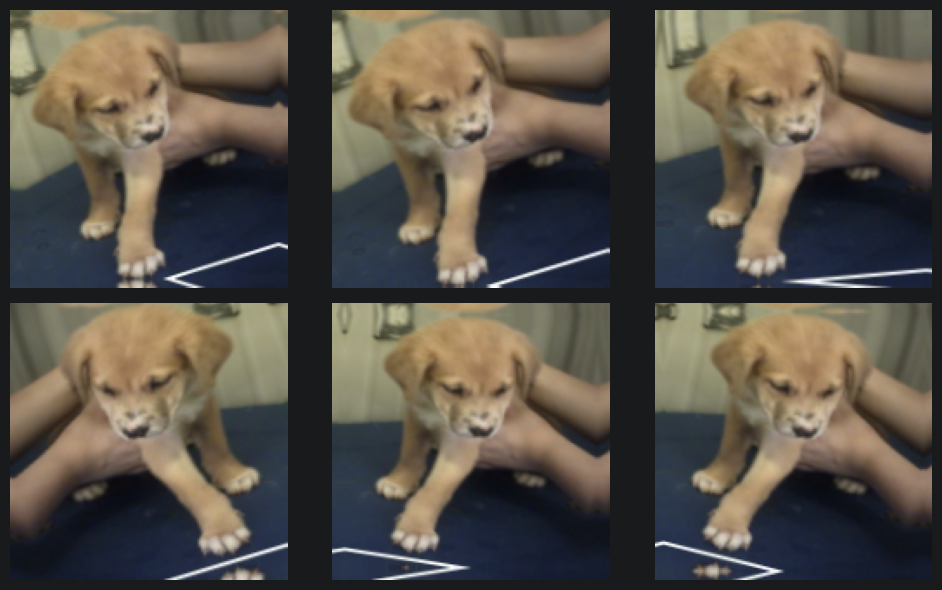

In [10]:
# Preview augmentation on one training image
for images, _ in train_dataset.take(1):
    sample_image = images[0]

plt.figure(figsize=(10, 6))
for i in range(6):
    ax = plt.subplot(2, 3, i + 1)
    augmented = data_augmentation(tf.expand_dims(sample_image, axis=0), training=True)
    plt.imshow(tf.cast(augmented[0], tf.uint8))
    plt.axis("off")

plt.tight_layout()
plt.show()


## 7. Load the pretrained backbone

MobileNetV2 was trained on ImageNet. We set <code>include_top=False</code> because its original 1,000-class ImageNet classifier does not match our cats-vs-dogs task.

At this stage, the backbone will act only as a feature extractor.


In [11]:
input_shape = IMG_SIZE + (3,)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=input_shape,
    include_top=False,
    weights="imagenet",
)

# Freeze every layer in the pretrained backbone.
base_model.trainable = False

print("Backbone name:", base_model.name)
print("Backbone output shape:", base_model.output_shape)
print("Number of backbone layers:", len(base_model.layers))


Backbone name: mobilenetv2_1.00_160
Backbone output shape: (None, 5, 5, 1280)
Number of backbone layers: 154


### Why freeze the backbone?

Freezing prevents gradient descent from changing pretrained weights while the new, randomly initialized classification head learns the target task.


In [12]:
def count_parameters(model):
    trainable = int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))
    non_trainable = int(np.sum([np.prod(v.shape) for v in model.non_trainable_weights]))
    return trainable, non_trainable

base_trainable, base_non_trainable = count_parameters(base_model)
print(f"Backbone trainable parameters:     {base_trainable:,}")
print(f"Backbone non-trainable parameters: {base_non_trainable:,}")


Backbone trainable parameters:     0
Backbone non-trainable parameters: 2,257,984


## 8. Add a new classification head

The pretrained backbone outputs spatial feature maps. Global Average Pooling converts each feature map into one value, Dropout adds regularization, and the final sigmoid unit predicts the probability of the positive class.

We call the backbone with <code>training=False</code>. This keeps Batch Normalization statistics in inference mode, which is especially important during later fine-tuning.


In [13]:
inputs = tf.keras.Input(shape=input_shape)

x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.20)(x)

outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs, name="cats_vs_dogs_transfer_model")
model.summary()


Model: "cats_vs_dogs_transfer_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

trainable_params, non_trainable_params = count_parameters(model)
print(f"Full model trainable parameters:     {trainable_params:,}")
print(f"Full model non-trainable parameters: {non_trainable_params:,}")


Full model trainable parameters:     1,281
Full model non-trainable parameters: 2,257,984


## 9. Stage 1 — Train only the new head

During this stage, MobileNetV2 remains unchanged. Only the new classifier learns from the cats-vs-dogs data.


In [15]:
frozen_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        FROZEN_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
    ),
]

history_frozen = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=INITIAL_EPOCHS,
    callbacks=frozen_callbacks,
)


Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 497ms/step - accuracy: 0.8338 - loss: 0.3919 - precision: 0.8692 - recall: 0.7808 - val_accuracy: 0.9620 - val_loss: 0.1117 - val_precision: 0.9825 - val_recall: 0.9375
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 542ms/step - accuracy: 0.9608 - loss: 0.1137 - precision: 0.9563 - recall: 0.9643 - val_accuracy: 0.9700 - val_loss: 0.0845 - val_precision: 0.9828 - val_recall: 0.9542
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 514ms/step - accuracy: 0.9657 - loss: 0.0928 - precision: 0.9608 - recall: 0.9705 - val_accuracy: 0.9680 - val_loss: 0.0785 - val_precision: 0.9828 - val_recall: 0.9500
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 542ms/step - accuracy: 0.9603 - loss: 0.0941 - precision: 0.9637 - recall: 0.9553 - val_accuracy: 0.9800 - val_loss: 0.0623 - val_precision: 0.9832 - val_recall: 0.9750
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 487ms/step - accuracy: 0.9750 - loss: 0.0768 - precision: 0.9722 - recall: 0.9768 - val_accuracy: 0.9820 - val_loss: 0.

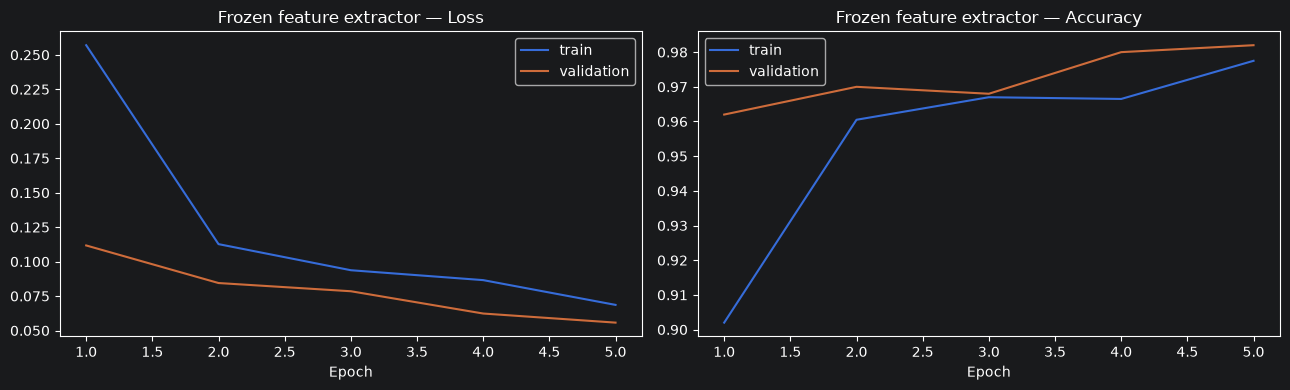

In [16]:
def plot_history(history, title):
    history_df = pd.DataFrame(history.history)
    epochs = np.arange(1, len(history_df) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(epochs, history_df["loss"], label="train")
    axes[0].plot(epochs, history_df["val_loss"], label="validation")
    axes[0].set_title(f"{title} — Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(epochs, history_df["accuracy"], label="train")
    axes[1].plot(epochs, history_df["val_accuracy"], label="validation")
    axes[1].set_title(f"{title} — Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_history(history_frozen, "Frozen feature extractor")


In [17]:
frozen_results = model.evaluate(test_dataset, return_dict=True, verbose=0)

print("Frozen-backbone test results")
for metric, value in frozen_results.items():
    print(f"{metric:>10}: {value:.4f}")


Frozen-backbone test results
  accuracy: 0.9820
      loss: 0.0594
 precision: 1.0000
    recall: 0.9820


## 10. Stage 2 — Fine-tune upper backbone layers

The new head has now learned a useful decision boundary. We can carefully adapt some high-level MobileNetV2 features to the target dataset.

Fine-tuning rules:

1. Train the new head before unfreezing the backbone.
2. Unfreeze upper layers first; they are usually more task-specific.
3. Use a learning rate much smaller than the feature-extraction learning rate.
4. Recompile the model after changing any <code>trainable</code> setting.
5. Keep Batch Normalization layers frozen or run the backbone with <code>training=False</code>.
6. Stop if validation loss starts to rise while training loss continues to fall.


In [18]:
# Unfreeze the backbone, then keep only the last 30 layers trainable.
base_model.trainable = True
UNFREEZE_LAST = 30
fine_tune_at = len(base_model.layers) - UNFREEZE_LAST

for index, layer in enumerate(base_model.layers):
    should_train = index >= fine_tune_at

    # Batch Normalization is kept frozen for stable fine-tuning.
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        should_train = False

    layer.trainable = should_train

trainable_backbone_layers = [layer.name for layer in base_model.layers if layer.trainable]

print("Fine-tuning starts at layer index:", fine_tune_at)
print("Trainable backbone layers:", len(trainable_backbone_layers))
print("First trainable layer:", trainable_backbone_layers[0])
print("Last trainable layer:", trainable_backbone_layers[-1])


Fine-tuning starts at layer index: 124
Trainable backbone layers: 19
First trainable layer: block_14_expand
Last trainable layer: out_relu


In [19]:
# Recompile after changing trainable layers.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

trainable_params, non_trainable_params = count_parameters(model)
print(f"Fine-tuning trainable parameters:     {trainable_params:,}")
print(f"Fine-tuning non-trainable parameters: {non_trainable_params:,}")


Fine-tuning trainable parameters:     1,512,001
Fine-tuning non-trainable parameters: 747,264


In [20]:
fine_tune_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        FINE_TUNED_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
    ),
]

completed_frozen_epochs = len(history_frozen.history["loss"])
total_epochs = completed_frozen_epochs + FINE_TUNE_EPOCHS

history_fine = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    initial_epoch=completed_frozen_epochs,
    epochs=total_epochs,
    callbacks=fine_tune_callbacks,
)


Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 42s 565ms/step - accuracy: 0.9786 - loss: 0.0652 - precision: 0.9780 - recall: 0.9788 - val_accuracy: 0.9820 - val_loss: 0.0445 - val_precision: 0.9833 - val_recall: 0.9792
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 38s 600ms/step - accuracy: 0.9755 - loss: 0.0541 - precision: 0.9689 - recall: 0.9828 - val_accuracy: 0.9800 - val_loss: 0.0495 - val_precision: 0.9915 - val_recall: 0.9667
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 511ms/step - accuracy: 0.9836 - loss: 0.0478 - precision: 0.9802 - recall: 0.9873 - val_accuracy: 0.9820 - val_loss: 0.0443 - val_precision: 0.9915 - val_recall: 0.9708
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 506ms/step - accuracy: 0.9867 - loss: 0.0310 - precision: 0.9830 - recall: 0.9899 - val_accuracy: 0.9800 - val_loss: 0.0479 - val_precision: 0.9915 - val_recall: 0.9667
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 493ms/step - accuracy: 0.9917 - loss: 0.0289 - precision: 0.9937 - recall: 0.9900 - val_accuracy: 0.9840 - val_lo

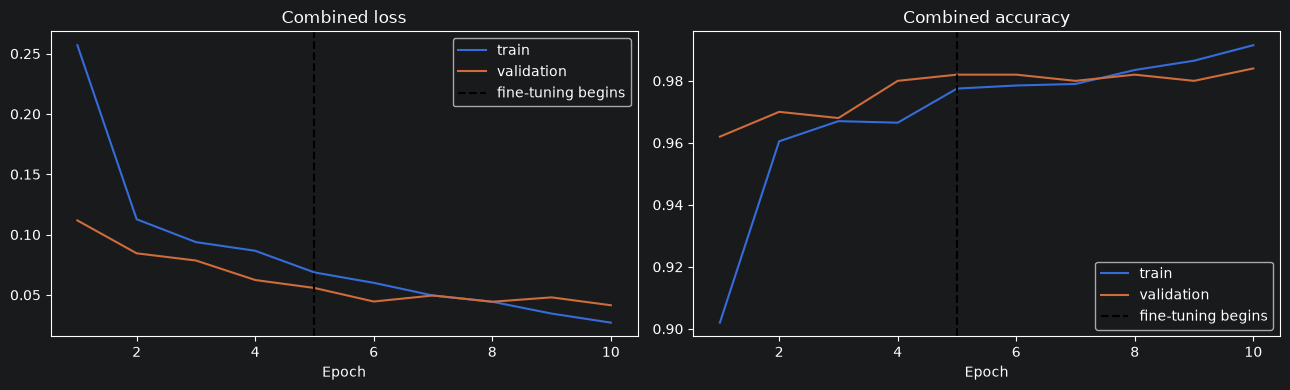

In [21]:
def plot_combined_histories(frozen_history, fine_history):
    train_accuracy = frozen_history.history["accuracy"] + fine_history.history["accuracy"]
    val_accuracy = frozen_history.history["val_accuracy"] + fine_history.history["val_accuracy"]
    train_loss = frozen_history.history["loss"] + fine_history.history["loss"]
    val_loss = frozen_history.history["val_loss"] + fine_history.history["val_loss"]

    epochs = np.arange(1, len(train_accuracy) + 1)
    boundary = len(frozen_history.history["accuracy"])

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(epochs, train_loss, label="train")
    axes[0].plot(epochs, val_loss, label="validation")
    axes[0].axvline(boundary, color="black", linestyle="--", label="fine-tuning begins")
    axes[0].set_title("Combined loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(epochs, train_accuracy, label="train")
    axes[1].plot(epochs, val_accuracy, label="validation")
    axes[1].axvline(boundary, color="black", linestyle="--", label="fine-tuning begins")
    axes[1].set_title("Combined accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_combined_histories(history_frozen, history_fine)


In [22]:
fine_tuned_results = model.evaluate(test_dataset, return_dict=True, verbose=0)

comparison = pd.DataFrame(
    [
        {"stage": "Frozen feature extractor", **frozen_results},
        {"stage": "Fine-tuned upper layers", **fine_tuned_results},
    ]
)

comparison


,stage,accuracy,loss,precision,recall
0,Frozen feature extractor,0.982,0.059362,1.0,0.982
1,Fine-tuned upper layers,0.982,0.041446,1.0,0.982


## 11. Inspect predictions, not only aggregate metrics

A model can have good accuracy and still fail systematically on a subset of images. Inspect the confusion matrix and several individual predictions.


2026-08-30 20:44:17.751121: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


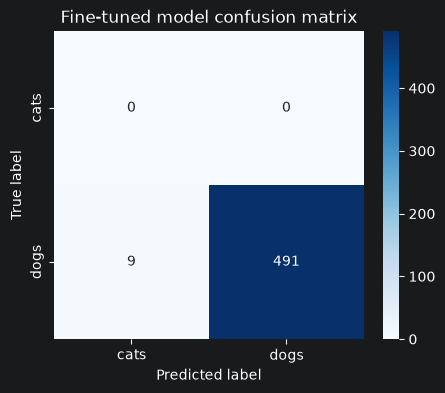

              precision    recall  f1-score   support

        cats       0.00      0.00      0.00         0
        dogs       1.00      0.98      0.99       500

    accuracy                           0.98       500
   macro avg       0.50      0.49      0.50       500
weighted avg       1.00      0.98      0.99       500



/Users/rmsaah/PycharmProjects/TuwaiqClasses/.venv312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/rmsaah/PycharmProjects/TuwaiqClasses/.venv312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/rmsaah/PycharmProjects/TuwaiqClasses/.venv312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

In [23]:
y_true = np.concatenate([labels.numpy() for _, labels in test_dataset]).astype(int)
y_probability = model.predict(test_dataset, verbose=0).ravel()
y_pred = (y_probability >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Fine-tuned model confusion matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))


2026-08-30 20:44:26.691449: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


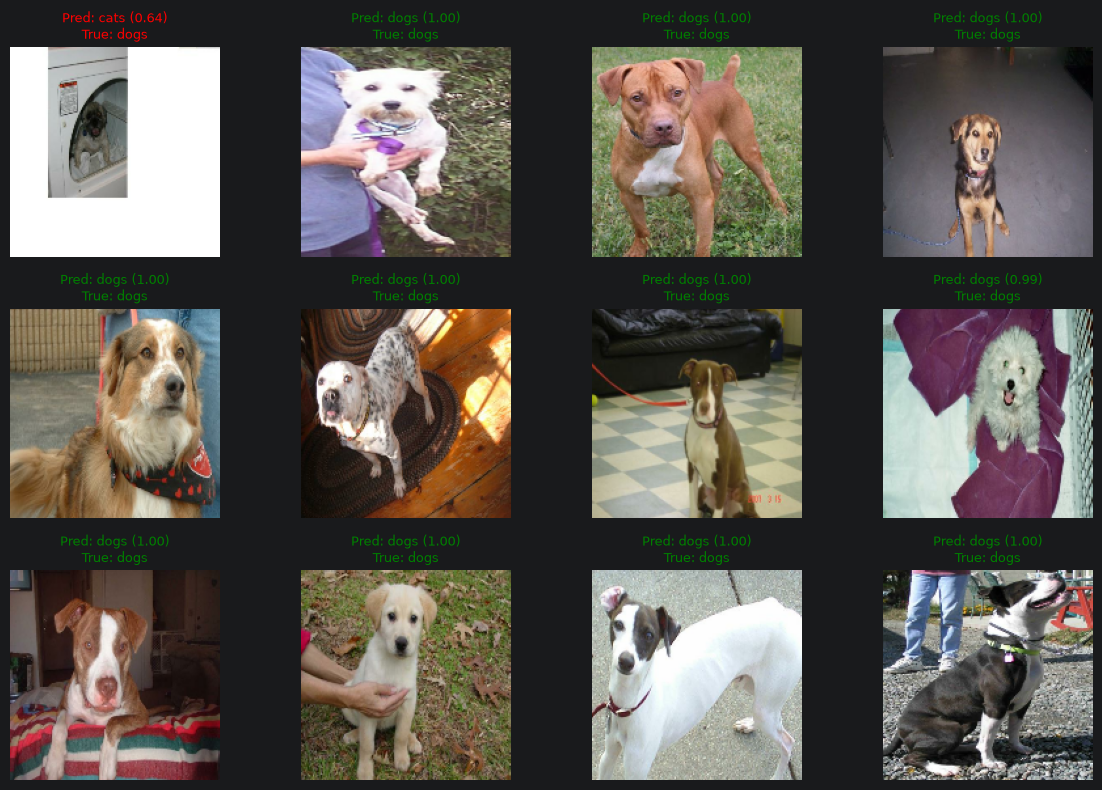

In [24]:
plt.figure(figsize=(12, 8))

for images, labels in test_dataset.take(1):
    probabilities = model.predict(images, verbose=0).ravel()

    for i in range(12):
        predicted_index = int(probabilities[i] >= 0.5)
        confidence = probabilities[i] if predicted_index == 1 else 1 - probabilities[i]
        true_index = int(labels[i])

        color = "green" if predicted_index == true_index else "red"

        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(
            f"Pred: {class_names[predicted_index]} ({confidence:.2f})\n"
            f"True: {class_names[true_index]}",
            color=color,
            fontsize=9,
        )
        plt.axis("off")

plt.tight_layout()
plt.show()


## 12. How to interpret the experiment

- **Fine-tuning improves validation and test results:** the pretrained upper features benefited from task-specific adaptation.
- **Training improves but validation becomes worse:** fine-tuning is overfitting; unfreeze fewer layers, reduce the learning rate, improve augmentation, or collect more data.
- **Little or no improvement:** frozen ImageNet features may already be sufficient, or the selected layers and learning rate may not be appropriate.
- **Both stages perform poorly:** inspect labels, class balance, image quality, and domain similarity before increasing model complexity.


# Student Task — Design a Better Fine-Tuning Strategy

## Scenario

You are given the trained frozen-feature model. Your goal is to improve its generalization **without changing the MobileNetV2 architecture or using the test set for model selection**.

## Required experiments

Run at least **three** fine-tuning experiments:

1. Unfreeze the last 10 layers using a learning rate of 1e-5.
2. Unfreeze the last 30 layers using a learning rate of 1e-5.
3. Design your own experiment by changing the number of unfrozen layers or the learning rate.

Each experiment must start from the same frozen-model checkpoint so the comparison is fair.


In [25]:
def create_fine_tuning_experiment(unfreeze_last, learning_rate):
    """Load the same frozen checkpoint and prepare a fair fine-tuning experiment."""

    experiment_model = tf.keras.models.load_model(FROZEN_MODEL_PATH)
    experiment_base = experiment_model.get_layer(base_model.name)
    experiment_base.trainable = True

    start_index = max(0, len(experiment_base.layers) - unfreeze_last)

    for index, layer in enumerate(experiment_base.layers):
        should_train = index >= start_index

        if isinstance(layer, tf.keras.layers.BatchNormalization):
            should_train = False

        layer.trainable = should_train

    experiment_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ],
    )

    return experiment_model


### Complete and run the experiment plan

The third configuration is intentionally incomplete. Choose a justified value based on what you learned.


In [26]:
experiments = [
    {"name": "Last 10 layers", "unfreeze_last": 10, "learning_rate": 1e-5},
    {"name": "Last 30 layers", "unfreeze_last": 30, "learning_rate": 1e-5},
    {
        "name": "My experiment",
        "unfreeze_last": None,      # TODO: choose a value
        "learning_rate": None,      # TODO: choose a value
    },
]

experiments


[{'name': 'Last 10 layers', 'unfreeze_last': 10, 'learning_rate': 1e-05},
 {'name': 'Last 30 layers', 'unfreeze_last': 30, 'learning_rate': 1e-05},
 {'name': 'My experiment', 'unfreeze_last': None, 'learning_rate': None}]

In [27]:
# Run this cell after completing every configuration above.
task_results = []

for config in experiments:
    if config["unfreeze_last"] is None or config["learning_rate"] is None:
        raise ValueError("Complete the TODO values in every experiment first.")

    print("\nRunning:", config["name"])

    experiment_model = create_fine_tuning_experiment(
        unfreeze_last=config["unfreeze_last"],
        learning_rate=config["learning_rate"],
    )

    checkpoint_name = (
        "task_"
        + config["name"].lower().replace(" ", "_")
        + ".keras"
    )

    experiment_history = experiment_model.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=4,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=1,
                restore_best_weights=True,
            ),
            tf.keras.callbacks.ModelCheckpoint(
                checkpoint_name,
                monitor="val_loss",
                save_best_only=True,
            ),
        ],
        verbose=1,
    )

    best_epoch = int(np.argmin(experiment_history.history["val_loss"]))

    task_results.append(
        {
            "experiment": config["name"],
            "unfrozen_layers_requested": config["unfreeze_last"],
            "learning_rate": config["learning_rate"],
            "best_epoch": best_epoch + 1,
            "val_loss": experiment_history.history["val_loss"][best_epoch],
            "val_accuracy": experiment_history.history["val_accuracy"][best_epoch],
            "val_precision": experiment_history.history["val_precision"][best_epoch],
            "val_recall": experiment_history.history["val_recall"][best_epoch],
            "model_path": checkpoint_name,
        }
    )

task_results_df = pd.DataFrame(task_results).sort_values(
    by="val_loss",
    ascending=True,
)

task_results_df



Running: Last 10 layers
Epoch 1/4
63/63 ━━━━━━━━━━━━━━━━━━━━ 44424s 716s/step - accuracy: 0.9692 - loss: 0.0801 - precision: 0.9605 - recall: 0.9787 - val_accuracy: 0.9820 - val_loss: 0.0569 - val_precision: 0.9873 - val_recall: 0.9750
Epoch 2/4
63/63 ━━━━━━━━━━━━━━━━━━━━ 40s 631ms/step - accuracy: 0.9745 - loss: 0.0638 - precision: 0.9690 - recall: 0.9796 - val_accuracy: 0.9820 - val_loss: 0.0540 - val_precision: 0.9873 - val_recall: 0.9750
Epoch 3/4
63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 505ms/step - accuracy: 0.9789 - loss: 0.0623 - precision: 0.9787 - recall: 0.9789 - val_accuracy: 0.9820 - val_loss: 0.0527 - val_precision: 0.9873 - val_recall: 0.9750
Epoch 4/4
63/63 ━━━━━━━━━━━━━━━━━━━━ 30s 478ms/step - accuracy: 0.9775 - loss: 0.0529 - precision: 0.9760 - recall: 0.9774 - val_accuracy: 0.9820 - val_loss: 0.0528 - val_precision: 0.9873 - val_recall: 0.9750

Running: Last 30 layers
Epoch 1/4
63/63 ━━━━━━━━━━━━━━━━━━━━ 40s 549ms/step - accuracy: 0.9735 - loss: 0.0656 - precision: 0.9687 - 

ValueError: Complete the TODO values in every experiment first.

### Final model selection

Select the final model using **validation evidence only**. Then evaluate that one model on the test set exactly once.


In [ ]:
SELECTED_MODEL_PATH = None  # TODO: copy the chosen model_path from the table

if SELECTED_MODEL_PATH is None:
    raise ValueError("Choose one model using validation results first.")

selected_model = tf.keras.models.load_model(SELECTED_MODEL_PATH)
final_test_results = selected_model.evaluate(
    test_dataset,
    return_dict=True,
    verbose=0,
)

print("Final test results")
for metric, value in final_test_results.items():
    print(f"{metric:>10}: {value:.4f}")


## Task questions

Answer each question using evidence from your experiments:

1. Which configuration achieved the best validation performance?
2. Why did you select this configuration before looking at the test result?
3. How did the number of unfrozen layers affect overfitting?
4. Why must the model be recompiled after changing trainable layers?
5. Why is the fine-tuning learning rate smaller than the feature-extraction learning rate?
6. What evidence would make you collect or clean data instead of tuning more layers?
7. Did the selected model generalize to the test set? Justify the final recommendation using at least three metrics or observations.

## Deliverables

- Completed notebook with all cells executed.
- One validation comparison table containing all experiments.
- One final test evaluation for the selected model.
- Training and validation curves for the selected model.
- Confusion matrix for the selected model.
- A 150–250 word conclusion explaining the final recommendation.

## Suggested grading rubric — 20 points

| Criterion | Points |
|---|---:|
| Correct transfer-learning workflow | 4 |
| Three valid fine-tuning experiments | 5 |
| Evaluation and comparison table | 4 |
| Error analysis and visual evidence | 3 |
| Technical justification and conclusion | 4 |


## Final takeaways

1. Transfer learning reuses representations learned from a large source task.
2. The original classifier is replaced because its classes do not match the target task.
3. Feature extraction freezes the backbone and trains only the new head.
4. Fine-tuning adapts some pretrained layers after the head has learned the new task.
5. Fine-tuning requires a small learning rate and recompilation.
6. Validation evidence—not training accuracy—should drive the unfreezing decision.
7. More trainable layers do not automatically produce a better model.


## References

- TensorFlow Core: [Transfer learning and fine-tuning](https://www.tensorflow.org/tutorials/images/transfer_learning)
- Keras: [Transfer learning and fine-tuning guide](https://keras.io/guides/transfer_learning/)
- Sandler et al.: [MobileNetV2: Inverted Residuals and Linear Bottlenecks](https://arxiv.org/abs/1801.04381)
